# Проверка гипотезы об эффективности нового алгоритма для развлекательной платформы

Основная цель продукта — удерживать внимание пользователя.

Монетизация приложения строится на двух моделях доступа к видео:

* Рекламная модель — бесплатный доступ к контенту, доход приносят рекламные ролики, встроенные в ленту.
* Подписочная модель — ежемесячная оплата, которая полностью отключает рекламу и делает просмотр беспрерывным.
Главный двигатель вашего приложения — это алгоритм рекомендаций.


>Рекомендательная система — это алгоритм, который из миллионов доступных вариантов выбирает те, которые с наибольшей вероятностью понравятся конкретному пользователю.
>Если алгоритм в приложении для коротких видео будет работать плохо (то есть будет отбирать неинтересный контент), пользователь быстро его закроет. Если хорошо — это создаст для пользователя стимул остаться в приложении дольше, что напрямую влияет на выручку компании.


До недавнего времени лента формировалась на основе простых эвристик, по схеме «популярное за день + новинки». Сейчас всё меняется: команда Data Science разработала новый алгоритм ранжирования контента.

В отличие от текущей системы, модель МО учитывает персональные интересы пользователя: его прошлые отметки «Нравится» и длительность просмотра. Модель оптимизирована на предсказание вероятности глубокого вовлечения (просмотр более 80% видео). Таким образом, более релевантный контент должен увеличивать время пользователей в приложении. Однако есть два риска, которые могут негативно повлиять на доходы:

1. Пользователи без подписки, максимально поглощённые релевантным контентом, могут начать негативно реагировать на рекламные вставки.
2. Ценность платной подписки «без рекламы» снизится, если контент станет слишком поглощающим.


## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Задача
- рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### Импорт необходимых библиотек и методов

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Импорт инструментов для расчёта мощности теста и эффекта
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

from math import ceil

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

In [4]:
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

display(sessions_history.head(), sessions_history.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


None

#### 1.2. Знакомство с данными

In [5]:
users_sessions = sessions_history.groupby('user_id')['session_id'].nunique()
max_user_sessions = users_sessions.idxmax()
max_user_sessions_df = sessions_history[sessions_history['user_id'] == max_user_sessions]
max_user_sessions_df.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android


#### Преобразование типов

In [6]:
sessions_history['session_date'] = pd.to_datetime(sessions_history['session_date'])
sessions_history['install_date'] = pd.to_datetime(sessions_history['install_date'])

#### 1.3. Анализ числа регистраций


In [7]:
unique_users_by_date = sessions_history.groupby('session_date')['user_id'].nunique().reset_index(name='n_users')
active_users_by_date = (
	sessions_history[sessions_history['registration_flag'] == 1].groupby('session_date')['user_id'].nunique().reset_index(name='n_reg')
)

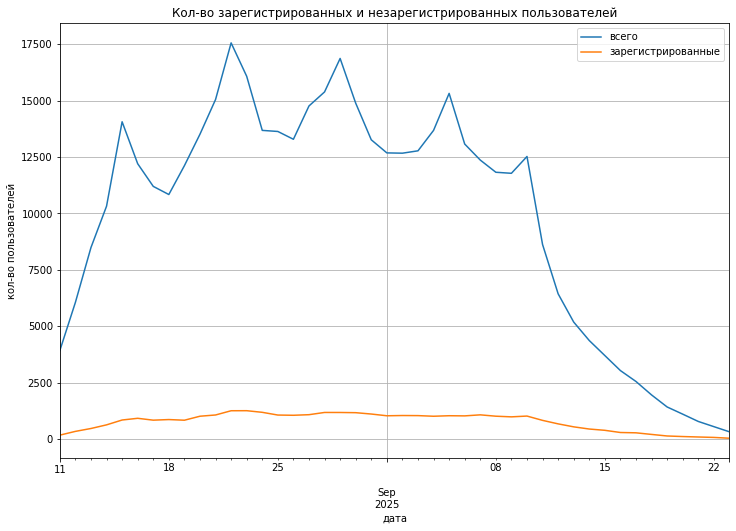

In [8]:
ax = unique_users_by_date.plot(kind='line', x='session_date', y='n_users', label='всего')
active_users_by_date.plot(kind='line', x='session_date', y='n_reg', label='зарегистрированные', grid=True, ax=ax)

plt.title('Кол-во зарегистрированных и незарегистрированных пользователей')
plt.xlabel('дата')
plt.ylabel('кол-во пользователей')
plt.legend()
plt.show()

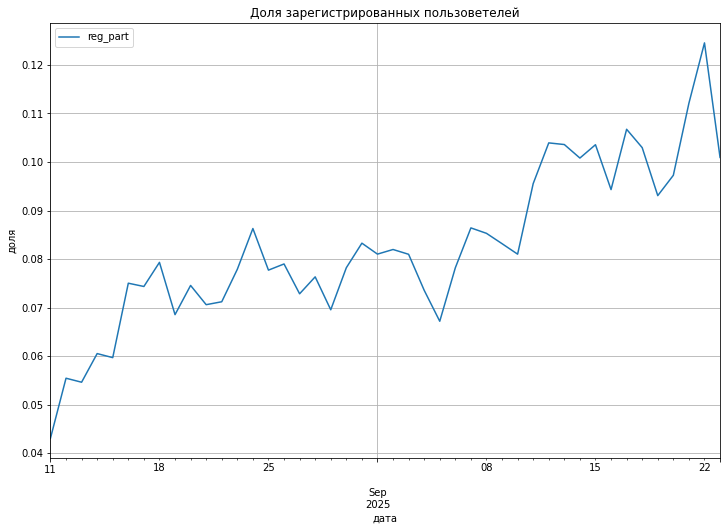

In [9]:
users_merged = pd.merge(left=unique_users_by_date, right=active_users_by_date, how='left', on='session_date')
users_merged['reg_part'] = users_merged['n_reg'] / users_merged['n_users']

users_merged.plot(kind='line', x='session_date', y='reg_part', grid=True)
plt.title('Доля зарегистрированных пользоветелей')
plt.xlabel('дата')
plt.ylabel('доля')
plt.show()

Анализ:
- доля зарегистрированных пользователей имеет тренд на рост

#### 1.4. Анализ числа просмотренных страниц


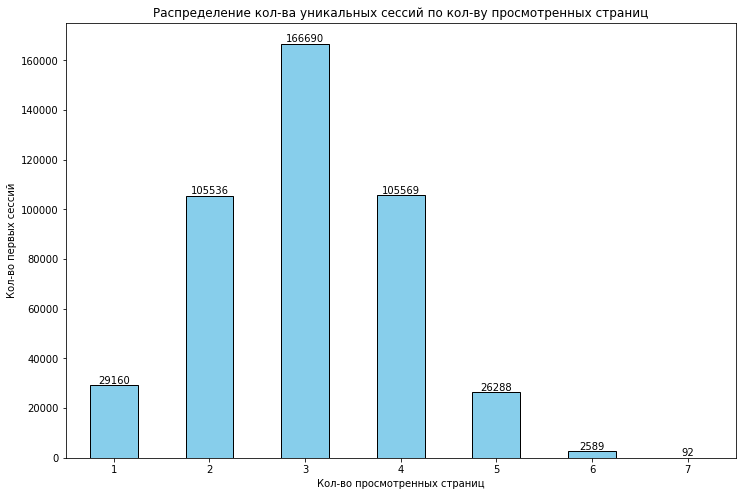

In [10]:
first_sessions = sessions_history.groupby(['session_date', 'user_id']).first().reset_index()

first_sessions_page_counter = first_sessions.groupby('page_counter')['session_id'].count().reset_index(name='n_first_sessions')

first_sessions_page_counter.plot.bar(
    x='page_counter', y='n_first_sessions', color='skyblue', edgecolor='black', legend=False
)
# подписи столбцов
for i, v in enumerate(first_sessions_page_counter['n_first_sessions'].values):
    plt.text(first_sessions_page_counter['n_first_sessions'].index[i], v, str(v), ha='center', va='bottom')
    
plt.xlabel('Кол-во просмотренных страниц')
plt.ylabel('Кол-во первых сессий')
plt.title('Распределение кол-ва уникальных сессий по кол-ву просмотренных страниц')
plt.xticks(rotation=0) 

plt.show()

Анализ:
- наиболее часто среди первых сессий встречается 3 просмотра страниц. 
- более 7ми страниц не встречается
- подавляющее большинство пользователей просматривают от 1 до 5 страниц. 6-7 довольно редко
- по форме распределение симметричное относительно 3х просмотров

#### 1.5. Доля пользователей, просмотревших более четырёх страниц


In [11]:
def calc_first_good_session_part(df: pd.DataFrame):
    """Расчет признака доли успешных первых сессий пользователей для каждого дня"""
    # первые сессии
    df_first_sessions = df[df['session_number'] == 1].copy()
    df_first_sessions['good_session'] = (df_first_sessions['page_counter'] >= 4).astype(int)
    success_first_sessions = df_first_sessions.groupby('session_date')['good_session'].mean().reset_index(name='success_first_sessions_part')
    return success_first_sessions

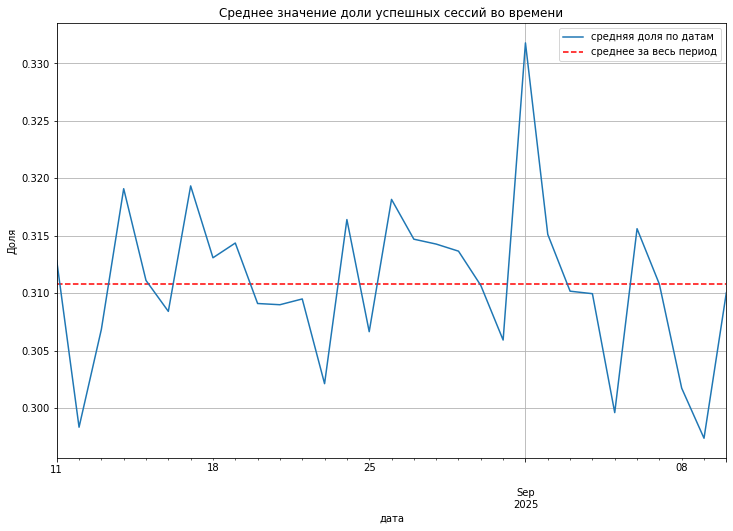

In [12]:
success_first_sessions = calc_first_good_session_part(df=sessions_history)
success_first_sessions.plot(kind='line', x='session_date', y='success_first_sessions_part', label='средняя доля по датам')

success_first_sessions_mean = success_first_sessions['success_first_sessions_part'].mean()
success_first_sessions_std = success_first_sessions['success_first_sessions_part'].std()

plt.hlines(
    y=success_first_sessions_mean, 
    xmin=success_first_sessions['session_date'].min(),
    xmax=success_first_sessions['session_date'].max(),
    colors='r',
    linestyles='--',
    label='среднее за весь период'
)

plt.title('Среднее значение доли успешных сессий во времени')
plt.xlabel('дата')
plt.ylabel('Доля')
plt.legend()
plt.grid()
plt.show()

Анализ:
- среднее значение доли успешных сессий варьируется в диапазоне от 0.29 до 0.33
- показатель осциллирует вблизи среденего значения, амплитуда разброса усиливается последнюю неделю 

### 2. Подготовка к тесту

- Определение целевой метрики.

- Рассчет необходимого размера выборки.

- рассчет необходимой длительности проведения теста.

#### 2.1. Расчёт размера выборки

Параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%.

In [ ]:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)
sample_size

3761.596974012117

#### 2.2. Расчёт длительности A/B-теста


In [14]:
unique_users_by_date.head()

,session_date,n_users
0,2025-08-11,3919
1,2025-08-12,6056
2,2025-08-13,8489
3,2025-08-14,10321
4,2025-08-15,14065


In [15]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = unique_users_by_date['n_users'].mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 1 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей
расчёт процентной разницы:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [16]:
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')
sessions_test_part.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3130 entries, 0 to 3129
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3130 non-null   object
 1   session_id         3130 non-null   object
 2   session_date       3130 non-null   object
 3   session_start_ts   3130 non-null   object
 4   install_date       3130 non-null   object
 5   session_number     3130 non-null   int64 
 6   registration_flag  3130 non-null   int64 
 7   page_counter       3130 non-null   int64 
 8   region             3130 non-null   object
 9   device             3130 non-null   object
 10  test_group         3130 non-null   object
dtypes: int64(3), object(8)
memory usage: 269.1+ KB


In [17]:
sessions_test_part['test_group'].unique()

array(['B', 'A'], dtype=object)

In [18]:
# кол-во уникальных пользователей по группам для одного дня наблюдения
n_unique_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
n_unique_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()
n_unique_a, n_unique_b


(1477, 1466)

Процентная разница A и B: 0.7447528774542992 %


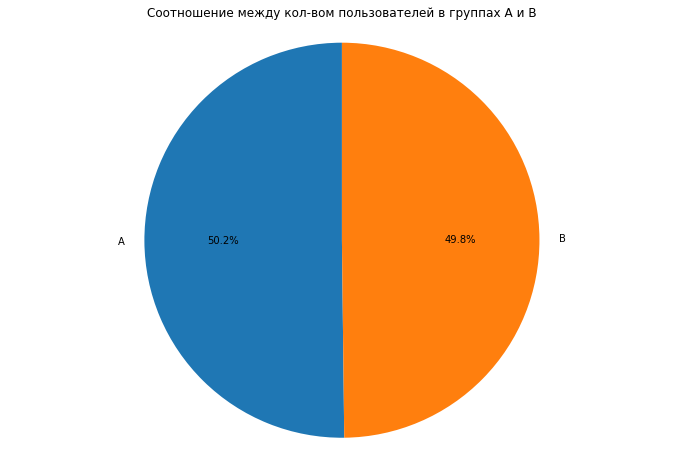

In [19]:
# процентная разница
p_ab_ratio = abs((n_unique_a - n_unique_b) / max(n_unique_a, n_unique_b)) * 100 
print(f'Процентная разница A и B: {p_ab_ratio} %')

plt.pie([n_unique_a, n_unique_b], labels=['A', 'B'], autopct="%1.1f%%", startangle=90)
plt.axis("equal")
plt.title("Соотношение между кол-вом пользователей в группах A и B")
plt.show()


Вывод:
- в группах A и B процентная разница между кол-вом пользователей менее 1%. Проверка распределения пользователей по группам пройдена успешно

#### 3.2. Проверка пересечений пользователей

In [20]:
unique_users_a = list(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
unique_users_b = list(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

users_intersection = set(unique_users_a) & set(unique_users_b)
users_intersection

set()

Вывод:
- пересечений нет, разделение по группам корректно. Выборки можно считать независимыми

#### 3.3. Равномерность разделения пользователей по устройствам


In [21]:
device_unique_users = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().reset_index(name='nunique_device_users')

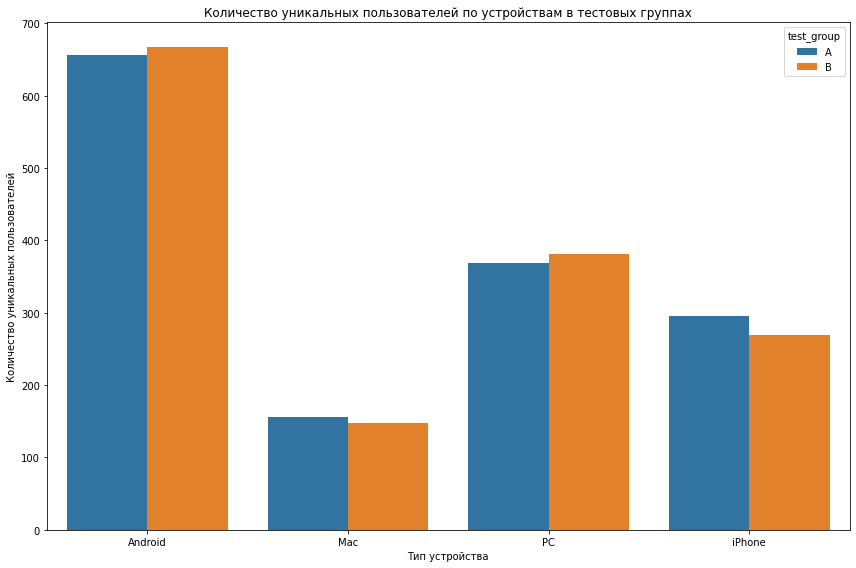

In [22]:
ax = sns.barplot(
    data=device_unique_users,
    x='device',
    y='nunique_device_users',
    hue='test_group',
)


plt.title('Количество уникальных пользователей по устройствам в тестовых группах')
plt.xlabel('Тип устройства')
plt.ylabel('Количество уникальных пользователей')
plt.tight_layout()
plt.show()

Вывод:
- распределения по устройствам среди групп A, B отличаются несущесвтенно. Разделение данных можно считать корректным

#### 3.4. Равномерность распределения пользователей по регионам

In [23]:
region_unique_users = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().reset_index(name='nunique_region_users')

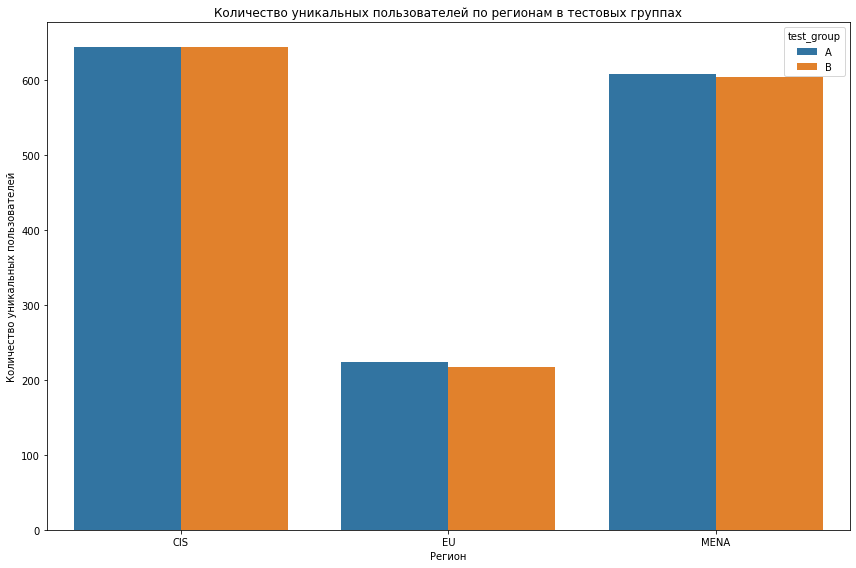

In [24]:
ax = sns.barplot(
    data=region_unique_users,
    x='region',
    y='nunique_region_users',
    hue='test_group',
)

plt.title('Количество уникальных пользователей по регионам в тестовых группах')
plt.xlabel('Регион')
plt.ylabel('Количество уникальных пользователей')
plt.tight_layout()
plt.show()

Вывод:
- распределение по регионам среди тестовых групп отличаются несущественно. Разбиение по регионам можно считать корректным


#### 3.5. Вывод после проверки A/B-теста

- разделение данных в части кол-ва пользователей корректно: различие менее 1% по уникальным пользователям
- пересечений среди пользователей в группах A,B не обнаружено - можем считать выборки независимыми
- анализ разпределений по категориальным признакам:
	- распределения по устройствам и регионам не имеют существенных различий - разбиение корректно

### 4. Проверка результатов A/B-теста

A/B-тест завершён, есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

In [25]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

display(sessions_test.info(), sessions_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            100005 non-null  object
 1   session_id         100005 non-null  object
 2   session_date       100005 non-null  object
 3   session_start_ts   100005 non-null  object
 4   install_date       100005 non-null  object
 5   session_number     100005 non-null  int64 
 6   registration_flag  100005 non-null  int64 
 7   page_counter       100005 non-null  int64 
 8   region             100005 non-null  object
 9   device             100005 non-null  object
 10  test_group         100005 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


None

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [26]:
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)
first_sessions = sessions_test[sessions_test['session_number'] == 1]


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Целевая метрика:
- доля успешных (глубоких первых сессий - `good_session`) за время проведения эксперимента.

Формулировка гипотез:
- $H_0: \mu_A = \mu_B$, где  $\mu$ - математическое ожидание доли глубоких сессий
- $H_1: \mu_A < \mu_B$


Дополнительные метрики (в теории можно вычислить, но в текущем проекте не рассчитываются):
- барьерные метрики: кол-во жалоб, плохих оценок, отказов от продления подписки 
- прокси метрики: доля подписок, хороших отзывов, рекомендаций друзьям, среденее кол-во сессий у пользователей

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [27]:
first_sessions.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0
7,457F2674E87EF6E7,14F71C18BE2CEC08,2025-10-19,2025-10-19 11:49:11,2025-10-19,1,0,3,MENA,Mac,A,0
8,57F342451921D207,76EFA055599ADE3C,2025-10-19,2025-10-19 18:47:43,2025-10-19,1,0,3,CIS,PC,A,0
9,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B,0
13,504F268CCCDB2CA9,2879394D4E1AB0A2,2025-10-17,2025-10-17 17:00:45,2025-10-17,1,0,3,CIS,iPhone,A,0


In [28]:
good_session_stat = (
    first_sessions
    .groupby('test_group')['good_session']
    .mean()
    .reset_index(name='success_first_sessions_part')
)

good_session_abs_diff = round(good_session_stat.iloc[1, 1] - good_session_stat.iloc[0, 1], 3)
good_session_rel_diff = round(
    good_session_abs_diff / max(good_session_stat.iloc[0, 1], good_session_stat.iloc[1, 1]),
    3
)

print('Целевая метрика: \n', good_session_stat)
print(f'\nАбсолютная разность: {good_session_abs_diff}, Относительная: {good_session_rel_diff}')

Целевая метрика: 
   test_group  success_first_sessions_part
0          A                     0.315724
1          B                     0.314673

Абсолютная разность: -0.001, Относительная: -0.003


#### 4.4. Насколько статистически значимо изменение ключевой метрики

In [29]:
# применение Z-теста для пропорций 
n_a = first_sessions[first_sessions['test_group'] == 'A'].shape[0]
n_b = first_sessions[first_sessions['test_group'] == 'B'].shape[0]

m_a = first_sessions[
    first_sessions['test_group'] == 'A'
]['good_session'].sum()

m_b = first_sessions[
    first_sessions['test_group'] == 'B'
]['good_session'].sum()

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='two-sided'
)


In [30]:
def stat_test_results(p_value: float, alpha: float, name: str):
	print('-'*50)
	print(f'Результаты статистического теста: {name}')

	if p_value >= alpha:
		print(f'Нет оснований для опровержения нулевой гипотезы: p_value={round(p_value, 4)} >={alpha=}')
	else:
		print(f'Нулевая гипотеза отвергается: p_value={round(p_value, 4)} < {alpha=}')

	print('-'*50)

In [31]:
stat_test_results(p_value=p_value_ztest, alpha=alpha, name='Z-тест пропорций')

--------------------------------------------------
Результаты статистического теста: Z-тест пропорций
Нет оснований для опровержения нулевой гипотезы: p_value=0.8433 >=alpha=0.05
--------------------------------------------------


Вывод:
- по результатам теста видно, что при p_value=0.8433 нет оснований отвергать нулевую гипотезу при заданном уровне статистической значимости alpha=0.05. Следовательно, новый алгоритм рекомендаций не оказал стат. значимого эффекта на глубину просмотра контента. 

#### 4.5. Вывод по результатам A/B-эксперимента

Проведен A/B эксперимент по оценке влияния нового алгоритма рекомендаций контента для пользователей.

Конфигурация теста:
- alpha = 0.05  # Уровень значимости
- Мощность теста: 0.8
- Базовый уровень доли: 0.3
- Минимальный детектируемый эффект: 0.03

Расчетные параметры:
- определен требуемый объем выборки: 3762 уникальных пользователя
- по данным об активных пользователях определена минимальная длительность эксперимента: 1 день

Результаты теста:
- Объем выборки для проведения тестов составил: 100_004 пользователей, что превосходит необходимый минимум. Тесту с таким объемом данных высокая степень доверия.
- согласно результатам двух статистических теста (Z-тест пропорций), новый алгоритм статистически значимо не повлиял на улучшение ключевой метрики доли глубоких первых сессий на заданном уровне статистической значимости alpha=0.05.
- Результаты тестов:
	- Z-тест пропорций: p_value=0.8433

Новый алгоритм рекомендаций контента нельзя рекомендовать к внедрению.